# Testing penultimate layer reconstruction
This notebook trains multiple "Regene" type models for varying dimensions, all with joint training of classifier and decoder.



## Setup


Set this to True if in Drive

In [6]:
inDrive = True

In [7]:
if inDrive:
    from google.colab import drive
    drive.mount('/content/drive')
    import os
    os.chdir('/content/drive/My Drive/Hybrid-CLUE/MyImplementation')
else:
    # Add parent directory to path so we can import modules
    import sys
    import os

    # Get the current directory
    current_dir = os.path.dirname(os.path.abspath('__file__'))

    # Get the parent directory
    parent_dir = os.path.dirname(current_dir)

    # Add the parent directory to sys.path
    if parent_dir not in sys.path:
        sys.path.append(parent_dir)

Mounted at /content/drive


In [8]:
training = True

Import libraries

In [9]:
import importlib
import models.regene_models as regene_models
importlib.reload(regene_models)
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

Set the device

In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


Load the Datasets

In [11]:
# Load the MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)

Set the latent dimension

In [12]:
latent_dim = 64

Create a models directory if it doesn't exist

In [13]:
# Create models directory in parent directory if it doesn't exist
os.makedirs(os.path.join('..', 'model_saves'), exist_ok=True)
model_saves_path = os.path.join('..', 'model_saves')

## Joint training


### Training
Train the models

Let's try training the models with a joint objective

In [14]:
from importlib import reload
import models.regene_models as regene_models
importlib.reload(regene_models)
from models.regene_models import Classifier, Decoder, train_joint

Alpha determines how much weight is given to the reconstruction loss.

In [16]:
dimensions = [16, 32, 64, 128, 256]

for latent_dim in dimensions:
    joint_decoder = regene_models.Decoder(latent_dim=latent_dim, device=device)
    joint_classifier = regene_models.Classifier(latent_dim=latent_dim, num_classes=10, device=device)

    regene_models.train_joint(joint_classifier, joint_decoder, trainloader, num_epochs=30, lr=0.001, lambda_recon=0.8, reconstruction_loss=nn.BCELoss())
    # Save models
    torch.save(joint_decoder.state_dict(), os.path.join(model_saves_path, f'joint_decoder_{latent_dim}.pth'))
    torch.save(joint_classifier.state_dict(), os.path.join(model_saves_path, f'joint_classifier_{latent_dim}.pth'))

Epoch [1/30], Train Total Loss: 0.1770, Train Classification Loss: 0.1691, Train Reconstruction Loss: 0.1790
Epoch [2/30], Train Total Loss: 0.1195, Train Classification Loss: 0.0488, Train Reconstruction Loss: 0.1372
Epoch [3/30], Train Total Loss: 0.1111, Train Classification Loss: 0.0358, Train Reconstruction Loss: 0.1299
Epoch [4/30], Train Total Loss: 0.1061, Train Classification Loss: 0.0276, Train Reconstruction Loss: 0.1258
Epoch [5/30], Train Total Loss: 0.1029, Train Classification Loss: 0.0229, Train Reconstruction Loss: 0.1229
Epoch [6/30], Train Total Loss: 0.0998, Train Classification Loss: 0.0177, Train Reconstruction Loss: 0.1203
Epoch [7/30], Train Total Loss: 0.0979, Train Classification Loss: 0.0147, Train Reconstruction Loss: 0.1187
Epoch [8/30], Train Total Loss: 0.0964, Train Classification Loss: 0.0128, Train Reconstruction Loss: 0.1174
Epoch [9/30], Train Total Loss: 0.0947, Train Classification Loss: 0.0104, Train Reconstruction Loss: 0.1158
Epoch [10/30], Trai

### Loading
Load the models

In [ ]:
joint_classifier.load_state_dict(torch.load(os.path.join(model_saves_path, 'joint_classifier.pth'), map_location=device))
joint_decoder.load_state_dict(torch.load(os.path.join(model_saves_path, 'joint_decoder.pth'), map_location=device))

RuntimeError: Error(s) in loading state_dict for Classifier:
	Missing key(s) in state_dict: "encoder.1.weight", "encoder.1.bias", "encoder.1.running_mean", "encoder.1.running_var", "encoder.4.weight", "encoder.4.bias", "encoder.5.weight", "encoder.5.bias", "encoder.5.running_mean", "encoder.5.running_var", "encoder.8.weight", "encoder.8.bias", "encoder.9.weight", "encoder.9.bias", "encoder.9.running_mean", "encoder.9.running_var", "encoder.13.weight", "encoder.13.bias". 
	Unexpected key(s) in state_dict: "encoder.3.weight", "encoder.3.bias", "encoder.6.weight", "encoder.6.bias", "encoder.10.weight", "encoder.10.bias". 
	size mismatch for classifier.weight: copying a param with shape torch.Size([10, 256]) from checkpoint, the shape in current model is torch.Size([10, 64]).

### Testing
Test the models


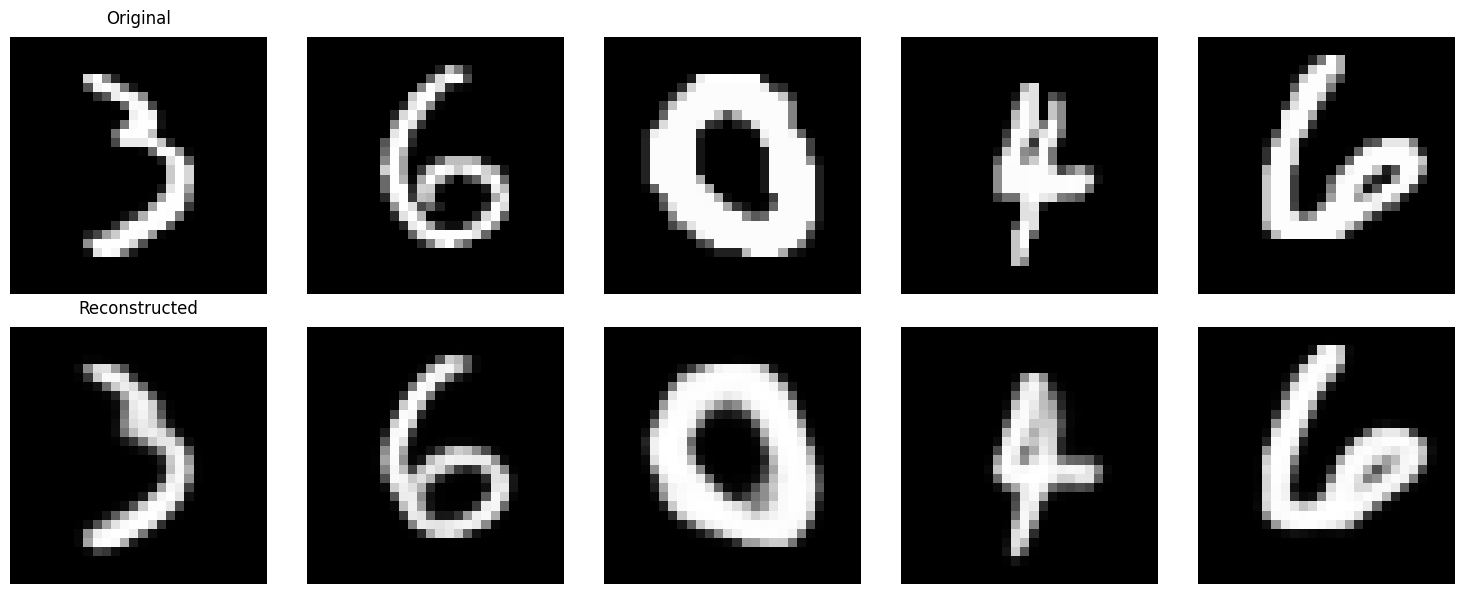

Average reconstruction MSE over 64 images: 0.004851


In [ ]:
import torch.nn.functional as F

# Get some test images
dataiter = iter(trainloader)
images, labels = next(dataiter)
images = images.to(device)

# Get reconstructions
with torch.no_grad():
    z, _ = joint_classifier(images)
    reconstructed = joint_decoder(z)

# Plot original vs reconstructed images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    # Original images
    axes[0,i].imshow(images[i].cpu().squeeze(), cmap='gray')
    axes[0,i].axis('off')
    if i == 0:
        axes[0,i].set_title('Original', pad=10)

    # Reconstructed images
    axes[1,i].imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
    axes[1,i].axis('off')
    if i == 0:
        axes[1,i].set_title('Reconstructed', pad=10)

plt.tight_layout()
plt.show()

# Calculate reconstruction error across 30+ images
mse_losses = []
num_batches = 0
total_images = 0

# Use test loader to get a more accurate measure
with torch.no_grad():
    for batch_images, _ in trainloader:
        batch_images = batch_images.to(device)
        z, _ = joint_classifier(batch_images)
        batch_reconstructed = joint_decoder(z)

        # Calculate MSE for this batch
        batch_mse = F.mse_loss(batch_reconstructed, batch_images).item()
        mse_losses.append(batch_mse)

        total_images += batch_images.size(0)
        num_batches += 1

        # Stop after we've processed at least 30 images
        if total_images >= 30:
            break

# Calculate average MSE
avg_mse = sum(mse_losses) / num_batches
print(f"Average reconstruction MSE over {total_images} images: {avg_mse:.6f}")


Average reconstruction MSE over 64 images: 0.006989
